# P300 EEG -> Adaptive-LIF SNN -> evidence -> drift-diffusion model (consolidated, fixed pipeline)
|

In [ ]:
import os, math, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, sosfiltfilt
from scipy.stats import norm, wilcoxon
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
DATA_ROOT = Path(os.environ.get("P300_DATA_ROOT", "../data"))   # folder that contains SBJ01/
SUBJECT = "SBJ01"
RESULTS = Path("results_snn_ddm"); RESULTS.mkdir(exist_ok=True)

FS = 250                 # Hz
EPOCH_START_S = -0.2     # epochs start 200 ms before the flash
N_OBJ = 8                # objects in the speller
BAND = (0.5, 20.0)       # Hz
WIN_S = 0.8              # keep 0-800 ms after the flash
POOL = 4                 # 4 samples = 16 ms per SNN time step -> 50 steps
PRE_BIN = 10             # pre-stimulus diagnostic bin (samples)
VAL_FRAC = 0.15          # fraction of training BLOCKS held out for early stopping + calibration

# DDM / decision settings
THETA_REF = 3.0                      # stopping boundary on cumulative LLR (log-odds), reference operating point
THETAS = [0.5, 1, 1.5, 2, 3, 4, 5, 6]  # boundary sweep for the speed-accuracy check
SEC_PER_REP = None                   # seconds per full repetition (8 flashes). Set it if you know the SOA; otherwise results stay in repetitions

np.random.seed(SEED)
print("Data root:", DATA_ROOT.resolve())

Data root: E:\IIT KGP IEEE\data


## 1. Load every session (Train and Test parts)

Each block has one attended object. Each run flashes every object once, so the k-th time an object appears inside a block is its k-th **repetition**. Block ids come from `runs_per_block.txt` when it is present (Test), otherwise 80 epochs per block (Train).

In [2]:
def read_ints(p):
    return np.loadtxt(p).astype(int).ravel()

def pick_eeg(mat, n_epochs):
    arrs = [np.asarray(v) for k, v in mat.items()
            if not k.startswith("__") and np.issubdtype(np.asarray(v).dtype, np.number)]
    A = max(arrs, key=lambda a: a.size)
    assert A.ndim == 3, f"expected a 3-D EEG array, got {A.shape}"
    ax_tr = [i for i, s in enumerate(A.shape) if s == n_epochs][0]
    rest = [i for i in range(3) if i != ax_tr]
    ax_t = rest[0] if A.shape[rest[0]] > A.shape[rest[1]] else rest[1]
    ax_c = [i for i in rest if i != ax_t][0]
    return np.transpose(A, (ax_tr, ax_c, ax_t))            # (epochs, channels, time)

def one_target_per_block(blk, y, ev):
    d = pd.DataFrame({"b": blk, "e": ev, "y": y})
    return bool((d[d.y == 1].groupby("b").e.nunique() == 1).all())

def blocks_from_target_changes(y, ev):
    # a run = 8 consecutive epochs (every object once); a new block starts when the attended object changes
    assert len(y) % N_OBJ == 0, "epoch count is not a multiple of the number of objects"
    r_ev, r_y = ev.reshape(-1, N_OBJ), y.reshape(-1, N_OBJ)
    ok = (np.sort(r_ev, axis=1) == np.arange(ev.min(), ev.min() + N_OBJ)).all(1) & (r_y.sum(1) == 1)
    if not ok.all():
        raise ValueError(f"{int((~ok).sum())} runs are not 8 epochs with each object once and exactly one target: "
                         "check the events/targets files")
    tgt = r_ev[np.arange(len(r_ev)), r_y.argmax(1)]
    run_blk = np.concatenate([[0], np.cumsum(tgt[1:] != tgt[:-1])])
    return np.repeat(run_blk, N_OBJ)

def make_blocks(y, ev, runs, default_per_block):
    n = len(y)
    cand = None
    if runs is not None and (runs * N_OBJ).sum() == n:
        cand = np.repeat(np.arange(len(runs)), runs * N_OBJ)
    elif n % default_per_block == 0:
        cand = np.arange(n) // default_per_block
    if cand is not None and one_target_per_block(cand, y, ev):
        return cand
    print("   note: block sizes from file/default are inconsistent with the targets, "
          "inferring blocks from changes of the attended object")
    return blocks_from_target_changes(y, ev)

def load_part(folder, prefix, default_per_block):
    y = read_ints(folder / f"{prefix}Targets.txt")
    ev = read_ints(folder / f"{prefix}Events.txt")
    X = pick_eeg(loadmat(folder / f"{prefix}Data.mat"), len(y))
    runs_file = folder / "runs_per_block.txt"
    runs = read_ints(runs_file) if runs_file.exists() else None
    blk = make_blocks(y, ev, runs, default_per_block)
    return X, y, ev, blk

subject_dir = DATA_ROOT / SUBJECT
session_dirs = sorted(p for p in subject_dir.glob("S*")
                      if p.is_dir() and (p / "Train").exists() and (p / "Test").exists())
assert session_dirs, f"no sessions found under {subject_dir}"
print("Sessions:", [p.name for p in session_dirs])

Sessions: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07']


## 2. Preprocessing (per session, no cross-trial statistics)

* 0.5-20 Hz zero-phase band-pass (second-order sections, numerically stable)
* baseline = mean of the 200 ms before the flash, subtracted
* keep 0-800 ms, average into 16 ms bins -> **50 SNN time steps x 8 channels**
* **No per-trial z-scoring.** Channel scaling is fitted on training folds only (done inside each fold).
* The raw pre-stimulus segment is kept for a leakage diagnostic.

In [3]:
N_BASE = int(round(-EPOCH_START_S * FS))      # 50 samples
N_WIN = int(round(WIN_S * FS))                # 200 samples
assert N_BASE % PRE_BIN == 0 and N_WIN % POOL == 0
SOS = butter(4, BAND, btype="band", fs=FS, output="sos")

def preprocess_epochs(X):
    Xf = sosfiltfilt(SOS, X.astype(np.float64), axis=-1)
    pre_raw = Xf[:, :, :N_BASE]
    pre = pre_raw.reshape(len(Xf), Xf.shape[1], -1, PRE_BIN).mean(-1).reshape(len(Xf), -1)
    Xc = Xf - pre_raw.mean(-1, keepdims=True)
    win = Xc[:, :, N_BASE:N_BASE + N_WIN]
    win = win.reshape(len(win), win.shape[1], -1, POOL).mean(-1)         # (N, C, 50)
    return win.transpose(0, 2, 1).astype(np.float32), pre.astype(np.float32)

Xb_l, pre_l, y_l, ev_l, blk_l, sess_l, part_l = [], [], [], [], [], [], []
blk_offset = 0
for si, sd in enumerate(session_dirs):
    for pi, (part, prefix, per_block) in enumerate((("Train", "train", 80), ("Test", "test", 48))):
        X, y, ev, blk = load_part(sd / part, prefix, per_block)
        xb, pre = preprocess_epochs(X)
        Xb_l.append(xb); pre_l.append(pre); y_l.append(y); ev_l.append(ev)
        blk_l.append(blk + blk_offset); blk_offset += int(blk.max()) + 1
        sess_l.append(np.full(len(y), si)); part_l.append(np.full(len(y), pi))
        print(f"  {sd.name}/{part:5s}: {len(y):5d} epochs, {int(y.sum()):4d} targets, "
              f"{int(blk.max()) + 1:3d} blocks, raw shape {X.shape}")
        del X

Xb = np.concatenate(Xb_l); PRE = np.concatenate(pre_l)
y_all = np.concatenate(y_l).astype(int); ev_all = np.concatenate(ev_l).astype(int)
blk_all = np.concatenate(blk_l); sess_all = np.concatenate(sess_l); part_all = np.concatenate(part_l)
del Xb_l, pre_l

tmp = pd.DataFrame({"b": blk_all, "e": ev_all})
rep_all = (tmp.groupby(["b", "e"]).cumcount() + 1).to_numpy()          # repetition index of that object in that block
N_TOT, T_STEPS, N_CH = Xb.shape
sessions = np.unique(sess_all)

# sanity: exactly one attended object per block, equal repetitions per object
chk = pd.DataFrame({"b": blk_all, "e": ev_all, "y": y_all})
n_tgt_obj = chk[chk.y == 1].groupby("b").e.nunique()
assert (n_tgt_obj == 1).all(), "a block has more than one target object: check targets/events files"
reps_per_obj = chk.groupby(["b", "e"]).size().groupby("b").nunique()
print(f"\nTotal epochs {N_TOT}, targets {int(y_all.sum())} ({y_all.mean():.1%}), blocks {len(np.unique(blk_all))}, "
      f"model input shape per epoch {Xb.shape[1:]}")
print("Blocks with unequal repetitions across objects:", int((reps_per_obj > 1).sum()))
print("Repetitions per block: min", int(chk.groupby("b").size().min() // N_OBJ),
      "max", int(chk.groupby("b").size().max() // N_OBJ))

  S01/Train:  1600 epochs,  200 targets,  20 blocks, raw shape (1600, 8, 350)
  S01/Test :  2400 epochs,  300 targets,  50 blocks, raw shape (2400, 8, 350)
  S02/Train:  1600 epochs,  200 targets,  20 blocks, raw shape (1600, 8, 350)
   note: block sizes from file/default are inconsistent with the targets, inferring blocks from changes of the attended object
  S02/Test :  2800 epochs,  350 targets,  41 blocks, raw shape (2800, 8, 350)
  S03/Train:  1600 epochs,  200 targets,  20 blocks, raw shape (1600, 8, 350)
   note: block sizes from file/default are inconsistent with the targets, inferring blocks from changes of the attended object
  S03/Test :  2800 epochs,  350 targets,  43 blocks, raw shape (2800, 8, 350)
  S04/Train:  1600 epochs,  200 targets,  20 blocks, raw shape (1600, 8, 350)
   note: block sizes from file/default are inconsistent with the targets, inferring blocks from changes of the attended object
  S04/Test :  3600 epochs,  450 targets,  46 blocks, raw shape (3600, 8, 

## 3. Leakage check: can the signal BEFORE the flash predict the label?

If this AUC is clearly above 0.5, overlap from the previous flash (short SOA) or an ordering artifact leaks label information, and any "early decision" claim is invalid. It should be about 0.5.

In [ ]:
cv_chk = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
auc_pre = cross_val_score(pipe, PRE, y_all, groups=blk_all, cv=cv_chk, scoring="roc_auc")
print(f"Pre-stimulus-only LDA (grouped 5-fold): AUC = {auc_pre.mean():.3f} +/- {auc_pre.std():.3f}")
if auc_pre.mean() > 0.55:
    print("  WARNING")
else:
    print("  OK: no meaningful pre-stimulus information, so post-stimulus AUC is not driven by this artifact.")

Pre-stimulus-only LDA (grouped 5-fold): AUC = 0.509 +/- 0.016
  OK: no meaningful pre-stimulus information, so post-stimulus AUC is not driven by this artifact.


## 4. Folds and the spatiotemporal LDA baseline

Outer protocol: **leave-one-session-out**. Inside each fold, 15% of the training *blocks* are held out as a validation set, used for early stopping and for calibrating scores into log-likelihood ratios. The held-out session is never used for any choice.

The LDA baseline uses 8 channels x 25 time bins (32 ms) = 200 features with automatic shrinkage. It uses exactly the same folds as the SNN.

In [5]:
folds = {}
for k in sessions:
    te = np.where(sess_all == k)[0]
    tr_all = np.where(sess_all != k)[0]
    ub = np.unique(blk_all[tr_all]); np.random.default_rng(SEED + int(k)).shuffle(ub)
    n_va = max(1, int(round(VAL_FRAC * len(ub))))
    va_mask = np.isin(blk_all[tr_all], ub[:n_va])
    folds[k] = dict(tr=tr_all[~va_mask], va=tr_all[va_mask], te=te)

def lda_features(X):
    n, t, c = X.shape
    return X.reshape(n, t // 2, 2, c).mean(2).reshape(n, -1)

F_lda = lda_features(Xb)
score = {"lda": np.full(N_TOT, np.nan, dtype=np.float32)}
val_store = {"lda": {}}
for k, f in folds.items():
    clf = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    clf.fit(F_lda[f["tr"]], y_all[f["tr"]])
    score["lda"][f["te"]] = clf.decision_function(F_lda[f["te"]])
    val_store["lda"][k] = (clf.decision_function(F_lda[f["va"]]), y_all[f["va"]])

auc_lda = {k: roc_auc_score(y_all[f["te"]], score["lda"][f["te"]]) for k, f in folds.items()}
print("LDA leave-one-session-out AUC per session:", {int(k): round(v, 3) for k, v in auc_lda.items()})
print(f"LDA mean AUC = {np.mean(list(auc_lda.values())):.3f} +/- {np.std(list(auc_lda.values()), ddof=1):.3f}")

LDA leave-one-session-out AUC per session: {0: 0.827, 1: 0.824, 2: 0.772, 3: 0.704, 4: 0.73, 5: 0.814, 6: 0.798}
LDA mean AUC = 0.781 +/- 0.048


## 5. Adaptive-LIF SNN


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")


H1, H2 = 64, 64
DROPOUT = 0.2
LR, WD = 3e-3, 1e-3
BATCH = 256
MAX_EPOCHS = 30
PATIENCE = 6
SURR_SLOPE = 4.0         # sharpness of the surrogate gradient
TARGET_RATE, RATE_REG = 0.10, 1e-2
AUG_SHIFT, AUG_NOISE = 2, 0.05     # +-2 bins (32 ms) circular shift, Gaussian noise (in scaled units)
N_SEEDS = 1              # use 3 for the final numbers
FOLDS_TO_RUN = None      # e.g. [0, 1] for a quick trial run; None = all sessions

class SpikeFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).float()
    @staticmethod
    def backward(ctx, g):
        (x,) = ctx.saved_tensors
        return g / (1.0 + SURR_SLOPE * x.abs()) ** 2
spike_fn = SpikeFn.apply

class AdLIF(nn.Module):
    def __init__(self, n_in, n_out, rho=0.9, b0=0.2, thr=1.0, gain=1.0):
        super().__init__()
        self.fc = nn.Linear(n_in, n_out)
        with torch.no_grad():
            self.fc.weight.mul_(gain)                       # larger init for the spike-driven layer so it does not start silent
        beta0 = torch.empty(n_out).uniform_(0.80, 0.97)
        self.beta_p = nn.Parameter(torch.log(beta0 / (1 - beta0)))
        self.b_p = nn.Parameter(torch.full((n_out,), math.log(math.expm1(b0))))
        self.rho, self.thr = rho, thr
    def forward(self, x):                                   # x: (B, T, n_in)
        cur = self.fc(x)                                    # all time steps in one matmul
        beta, b = torch.sigmoid(self.beta_p), F.softplus(self.b_p)
        B, T, Hn = cur.shape
        v = cur.new_zeros(B, Hn); a = cur.new_zeros(B, Hn)
        out = []
        for t in range(T):
            v = beta * v + cur[:, t] - a
            s = spike_fn(v - self.thr)
            v = v - s.detach() * self.thr                   # soft reset
            a = self.rho * a + b * s                        # spike-frequency adaptation
            out.append(s)
        return torch.stack(out, dim=1)                      # (B, T, Hn)

class P300SNN(nn.Module):
    def __init__(self, n_in=8, h1=H1, h2=H2, T=50, drop=DROPOUT):
        super().__init__()
        self.l1, self.l2 = AdLIF(n_in, h1, gain=1.0), AdLIF(h1, h2, gain=2.0)
        self.drop = nn.Dropout(drop)
        self.ro = nn.Linear(h2, 1, bias=False)
        self.ro_beta_p = nn.Parameter(torch.tensor(math.log(0.95 / 0.05)))
        self.tw = nn.Parameter(torch.zeros(T))              # temporal pooling weights (softmax)
        self.bias = nn.Parameter(torch.zeros(1))
    def forward(self, x):                                   # x: (B, T, C)
        s1 = self.l1(x)
        s2 = self.l2(self.drop(s1))
        cur = self.ro(self.drop(s2)).squeeze(-1)            # (B, T)
        beta = torch.sigmoid(self.ro_beta_p)
        v = cur.new_zeros(cur.shape[0]); E = []
        for t in range(cur.shape[1]):
            v = beta * v + cur[:, t]
            E.append(v)
        E = torch.stack(E, dim=1)                           # evidence trajectory E(t)
        logit = (E * torch.softmax(self.tw, 0)).sum(1) + self.bias
        return logit, E, (s1.mean(), s2.mean())

@torch.no_grad()
def predict(model, X, bs=512):
    model.eval(); zs, Es, r1, r2 = [], [], [], []
    for i in range(0, len(X), bs):
        z, E, (a, b) = model(X[i:i + bs])
        zs.append(z.float().cpu()); Es.append(E.float().cpu()); r1.append(float(a)); r2.append(float(b))
    return torch.cat(zs).numpy(), torch.cat(Es).numpy(), (np.mean(r1), np.mean(r2))

def train_one(Xtr, ytr, Xva, yva, seed, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = P300SNN(n_in=Xtr.shape[2], T=Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    n_pos, n_neg = float((ytr == 1).sum()), float((ytr == 0).sum())
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(math.sqrt(n_neg / n_pos), device=DEVICE))
    best, best_state, bad = -1.0, None, 0
    yva_np = yva.cpu().numpy()
    for ep in range(MAX_EPOCHS):
        model.train(); t0 = time.time()
        perm = torch.randperm(len(Xtr), device=DEVICE)
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            xb, yb = Xtr[idx], ytr[idx]
            if AUG_SHIFT > 0:
                sh = int(torch.randint(-AUG_SHIFT, AUG_SHIFT + 1, (1,)))
                if sh: xb = torch.roll(xb, sh, dims=1)
            if AUG_NOISE > 0:
                xb = xb + AUG_NOISE * torch.randn_like(xb)
            logit, _, rates = model(xb)
            loss = bce(logit, yb) + RATE_REG * sum((r - TARGET_RATE) ** 2 for r in rates)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sched.step()
        zv, _, rt = predict(model, Xva)
        auc = roc_auc_score(yva_np, zv)
        if verbose and (ep % 3 == 0 or ep == MAX_EPOCHS - 1):
            print(f"    ep {ep + 1:02d} loss {loss.item():.3f} val AUC {auc:.3f} rates L1 {rt[0]:.3f} L2 {rt[1]:.3f} ({time.time() - t0:.1f}s/ep)")
        if auc > best + 1e-4:
            best, bad = auc, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE: break
    model.load_state_dict(best_state)
    return model, best

Device: cuda NVIDIA GeForce RTX 2050


## 6. Train and evaluate the SNN, leave-one-session-out

In [7]:
score["snn"] = np.full(N_TOT, np.nan, dtype=np.float32)
val_store["snn"] = {}
E_traj = np.full((N_TOT, T_STEPS), np.nan, dtype=np.float32)
snn_rates = {}
run_list = list(sessions) if FOLDS_TO_RUN is None else [s for s in sessions if int(s) in FOLDS_TO_RUN]

for k in run_list:
    f = folds[k]
    mu = Xb[f["tr"]].mean(axis=(0, 1), keepdims=True); sd = Xb[f["tr"]].std(axis=(0, 1), keepdims=True) + 1e-8
    to_t = lambda idx: torch.tensor((Xb[idx] - mu) / sd, dtype=torch.float32, device=DEVICE)
    Xtr, Xva, Xte = to_t(f["tr"]), to_t(f["va"]), to_t(f["te"])
    ytr = torch.tensor(y_all[f["tr"]], dtype=torch.float32, device=DEVICE)
    yva = torch.tensor(y_all[f["va"]], dtype=torch.float32, device=DEVICE)
    print(f"\n=== Held-out session {int(k)} | train {len(f['tr'])} (targets {int(ytr.sum())}) val {len(f['va'])} test {len(f['te'])} ===")
    zv_s, zt_s, Et_s = [], [], []
    for sidx in range(N_SEEDS):
        model, best = train_one(Xtr, ytr, Xva, yva, seed=SEED + 100 * int(k) + sidx)
        zv, _, _ = predict(model, Xva); zt, Et, rt = predict(model, Xte)
        zv_s.append(zv); zt_s.append(zt); Et_s.append(Et); snn_rates[(int(k), sidx)] = rt
        print(f"  seed {sidx}: best val AUC {best:.3f} | test AUC {roc_auc_score(y_all[f['te']], zt):.3f}")
        torch.save(model.state_dict(), RESULTS / f"snn_fold{int(k)}_seed{sidx}.pt")
    score["snn"][f["te"]] = np.mean(zt_s, axis=0)
    E_traj[f["te"]] = np.mean(Et_s, axis=0)
    val_store["snn"][k] = (np.mean(zv_s, axis=0), y_all[f["va"]])
    print(f"  ensemble test AUC {roc_auc_score(y_all[f['te']], score['snn'][f['te']]):.3f} "
          f"(LDA {auc_lda[k]:.3f})")
    del Xtr, Xva, Xte
    if DEVICE.type == "cuda": torch.cuda.empty_cache()


=== Held-out session 0 | train 22360 (targets 2795) val 4040 test 4000 ===
    ep 01 loss 0.693 val AUC 0.475 rates L1 0.062 L2 0.018 (9.1s/ep)
    ep 04 loss 0.707 val AUC 0.540 rates L1 0.063 L2 0.017 (8.4s/ep)
    ep 07 loss 0.782 val AUC 0.569 rates L1 0.065 L2 0.016 (8.2s/ep)
    ep 10 loss 0.638 val AUC 0.603 rates L1 0.070 L2 0.020 (8.2s/ep)
    ep 13 loss 0.440 val AUC 0.632 rates L1 0.077 L2 0.023 (8.3s/ep)
    ep 16 loss 0.637 val AUC 0.645 rates L1 0.085 L2 0.029 (8.7s/ep)
    ep 19 loss 0.863 val AUC 0.651 rates L1 0.091 L2 0.033 (8.1s/ep)
    ep 22 loss 0.687 val AUC 0.656 rates L1 0.092 L2 0.036 (8.1s/ep)
    ep 25 loss 0.680 val AUC 0.660 rates L1 0.094 L2 0.037 (8.9s/ep)
    ep 28 loss 0.497 val AUC 0.661 rates L1 0.095 L2 0.037 (8.4s/ep)
    ep 30 loss 0.707 val AUC 0.660 rates L1 0.095 L2 0.037 (8.3s/ep)
  seed 0: best val AUC 0.662 | test AUC 0.700
  ensemble test AUC 0.700 (LDA 0.827)

=== Held-out session 1 | train 22160 (targets 2770) val 3840 test 4400 ===
    e

## 7. Single-trial classification: SNN vs LDA (held-out sessions)

 session  n_test  n_targets  auc_snn  auc_lda   diff
       0    4000        500    0.700    0.827 -0.127
       1    4400        550    0.672    0.824 -0.153
       2    4400        550    0.652    0.772 -0.121
       3    5200        650    0.665    0.704 -0.040
       4    3600        450    0.661    0.730 -0.069
       5    4400        550    0.665    0.814 -0.148
       6    4400        550    0.625    0.798 -0.173

SNN AUC 0.663 +/- 0.022 | LDA AUC 0.781 +/- 0.048 | mean diff (SNN - LDA) -0.118
Paired Wilcoxon signed-rank over sessions: p = 0.0156

Evidence E(t): peak mean AUC 0.657 at 568 ms; 90% of peak reached at 536 ms
Neural onset latency per session (ms, first 3 consecutive bins with AUC > 0.5 + 2 SE): {0: 472, 1: 472, 2: 456, 3: 472, 4: 440, 5: 440, 6: 472}


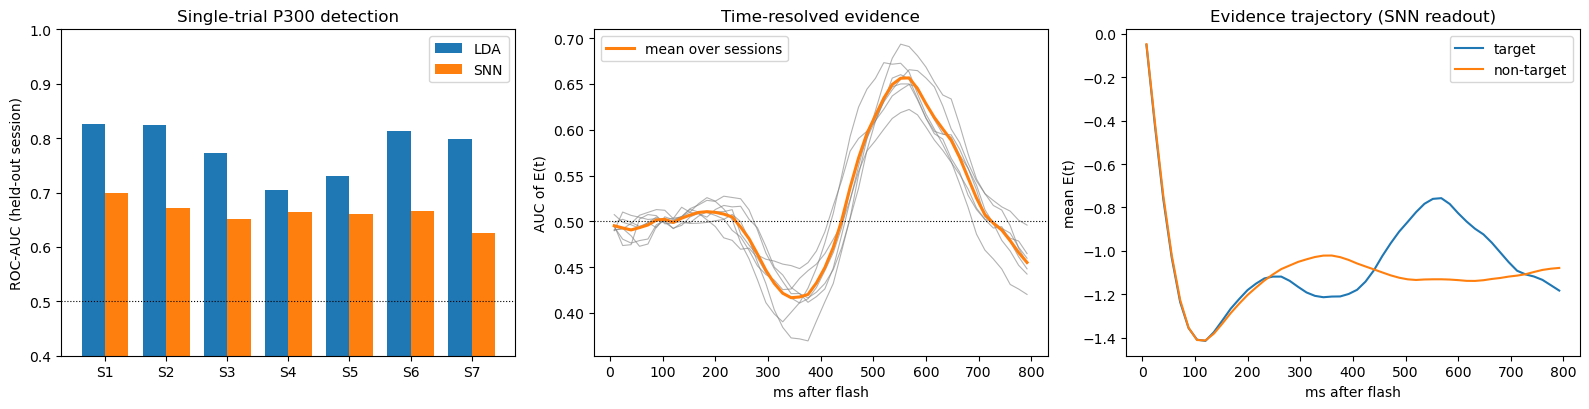

In [8]:
sess_eval = [k for k in sessions if np.isfinite(score["snn"][folds[k]["te"]]).all()]
rows = []
for k in sess_eval:
    te = folds[k]["te"]
    rows.append(dict(session=int(k), n_test=len(te), n_targets=int(y_all[te].sum()),
                     auc_snn=roc_auc_score(y_all[te], score["snn"][te]),
                     auc_lda=roc_auc_score(y_all[te], score["lda"][te])))
res_auc = pd.DataFrame(rows)
res_auc["diff"] = res_auc.auc_snn - res_auc.auc_lda
print(res_auc.round(3).to_string(index=False))
n_s = len(res_auc)
print(f"\nSNN AUC {res_auc.auc_snn.mean():.3f} +/- {res_auc.auc_snn.std(ddof=1):.3f} | "
      f"LDA AUC {res_auc.auc_lda.mean():.3f} +/- {res_auc.auc_lda.std(ddof=1):.3f} | "
      f"mean diff (SNN - LDA) {res_auc['diff'].mean():+.3f}")
if n_s >= 6:
    print("Paired Wilcoxon signed-rank over sessions: p =", round(wilcoxon(res_auc.auc_snn, res_auc.auc_lda).pvalue, 4))
res_auc.to_csv(RESULTS / "single_trial_auc.csv", index=False)

# time-resolved AUC of the evidence trajectory E(t) over 0-800 ms
t_ms = (np.arange(T_STEPS) + 0.5) * POOL * 1000 / FS

def hm_se(auc, n1, n0):
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return np.sqrt((auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n0 - 1) * (q2 - auc ** 2)) / (n1 * n0))

auc_t, onset_ms = {}, {}
for k in sess_eval:
    te = folds[k]["te"]; yt = y_all[te]; n1, n0 = int(yt.sum()), int((yt == 0).sum())
    a = np.array([roc_auc_score(yt, E_traj[te, t]) for t in range(T_STEPS)])
    auc_t[k] = a
    sig = a > 0.5 + 2 * hm_se(a, n1, n0)
    run3 = [i for i in range(T_STEPS - 2) if sig[i] and sig[i + 1] and sig[i + 2]]
    onset_ms[k] = t_ms[run3[0]] if run3 else np.nan
A_t = np.vstack([auc_t[k] for k in sess_eval])
mean_curve = A_t.mean(0)
peak_i = int(np.argmax(mean_curve))
t90 = t_ms[int(np.argmax(mean_curve >= 0.5 + 0.9 * (mean_curve.max() - 0.5)))]
print(f"\nEvidence E(t): peak mean AUC {mean_curve.max():.3f} at {t_ms[peak_i]:.0f} ms; 90% of peak reached at {t90:.0f} ms")
print("Neural onset latency per session (ms, first 3 consecutive bins with AUC > 0.5 + 2 SE):",
      {int(k): (None if np.isnan(v) else int(v)) for k, v in onset_ms.items()})

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
w = 0.38; xs = np.arange(n_s)
ax[0].bar(xs - w / 2, res_auc.auc_lda, w, label="LDA"); ax[0].bar(xs + w / 2, res_auc.auc_snn, w, label="SNN")
ax[0].axhline(0.5, color="k", lw=0.8, ls=":"); ax[0].set_xticks(xs); ax[0].set_xticklabels([f"S{s + 1}" for s in res_auc.session])
ax[0].set_ylim(0.4, 1.0); ax[0].set_ylabel("ROC-AUC (held-out session)"); ax[0].set_title("Single-trial P300 detection"); ax[0].legend()
for a in A_t: ax[1].plot(t_ms, a, color="gray", lw=0.8, alpha=0.6)
ax[1].plot(t_ms, mean_curve, color="C1", lw=2.2, label="mean over sessions")
ax[1].axhline(0.5, color="k", lw=0.8, ls=":"); ax[1].set_xlabel("ms after flash"); ax[1].set_ylabel("AUC of E(t)")
ax[1].set_title("Time-resolved evidence"); ax[1].legend()
te_all = np.concatenate([folds[k]["te"] for k in sess_eval])
for c, lab in ((1, "target"), (0, "non-target")):
    ax[2].plot(t_ms, np.nanmean(E_traj[te_all][y_all[te_all] == c], 0), label=lab)
ax[2].set_xlabel("ms after flash"); ax[2].set_ylabel("mean E(t)"); ax[2].set_title("Evidence trajectory (SNN readout)"); ax[2].legend()
plt.tight_layout(); plt.savefig(RESULTS / "fig1_single_trial_and_temporal.png", dpi=200); plt.show()

## 8. From scores to evidence: calibrated log-likelihood ratios

Each flash score is mapped to a log-likelihood ratio with an equal-variance Gaussian model fitted on the **validation blocks of the same fold** (never on the held-out session):

`LLR(z) = (mu1 - mu0) / sigma^2 * (z - (mu1 + mu0) / 2)`, with sensitivity `d' = (mu1 - mu0) / sigma`.

Under this model the LLR increments have mean `+-d'^2/2` and standard deviation `d'`, which is exactly a drift-diffusion process once divided by `d'`: drift `+-d'/2` per repetition, unit noise.

In [9]:
def fit_llr(zv, yv):
    m1, m0 = zv[yv == 1].mean(), zv[yv == 0].mean()
    var = (((zv[yv == 1] - m1) ** 2).sum() + ((zv[yv == 0] - m0) ** 2).sum()) / (len(zv) - 2)
    return (m1 - m0) / var, (m1 + m0) / 2, (m1 - m0) / np.sqrt(var)

methods = ["snn", "lda"]
llr = {m: np.full(N_TOT, np.nan) for m in methods}
dprime = {m: {} for m in methods}
for m in methods:
    for k in sess_eval:
        gain, mid, d = fit_llr(*val_store[m][k])
        te = folds[k]["te"]
        llr[m][te] = gain * (score[m][te] - mid)
        dprime[m][k] = d
print("Validation d' per session  SNN:", {int(k): round(float(v), 2) for k, v in dprime["snn"].items()})
print("                            LDA:", {int(k): round(float(v), 2) for k, v in dprime["lda"].items()})

ev_mask = np.isin(sess_all, sess_eval)
df = pd.DataFrame({"sess": sess_all, "blk": blk_all, "obj": ev_all, "rep": rep_all, "y": y_all,
                   "llr_snn": llr["snn"], "llr_lda": llr["lda"]})[ev_mask]

def build_trials(df, col):
    # one trial = one (block, object); increments are the per-repetition LLRs
    d = df.sort_values(["blk", "obj", "rep"])
    g = d.groupby(["blk", "obj"], sort=True)
    tid = g.ngroup().to_numpy(); pos = g.cumcount().to_numpy()
    R = np.bincount(tid); n_tr = len(R)
    inc = np.full((n_tr, R.max()), np.nan); inc[tid, pos] = d[col].to_numpy()
    first = np.r_[0, np.cumsum(R)[:-1]]
    return dict(inc=inc, R=R, y=d["y"].to_numpy()[first], sess=d["sess"].to_numpy()[first],
                blk=d["blk"].to_numpy()[first], obj=d["obj"].to_numpy()[first])

trials = {m: build_trials(df, f"llr_{m}") for m in methods}
print("Trials (block x object):", len(trials["snn"]["R"]), "| targets:", int(trials["snn"]["y"].sum()),
      "| repetitions per trial: min", int(trials["snn"]["R"].min()), "max", int(trials["snn"]["R"].max()))

Validation d' per session  SNN: {0: 0.52, 1: 0.58, 2: 0.58, 3: 0.53, 4: 0.54, 5: 0.63, 6: 0.63}
                            LDA: {0: 0.9, 1: 1.12, 2: 1.11, 3: 1.08, 4: 1.11, 5: 1.0, 6: 1.09}
Trials (block x object): 3616 | targets: 452 | repetitions per trial: min 5 max 42


## 9. Speller-level result: accuracy vs number of repetitions



Speller accuracy (8-way, mean over sessions; chance = 12.5%):
     snn_mean  snn_sd  lda_mean  lda_sd
rep                                    
1       0.226   0.042     0.403   0.120
2       0.305   0.086     0.520   0.139
3       0.352   0.086     0.591   0.114
4       0.387   0.073     0.639   0.125
5       0.430   0.082     0.714   0.122
6       0.482   0.101     0.747   0.109
7       0.535   0.091     0.802   0.129
8       0.540   0.106     0.780   0.118
9       0.541   0.107     0.795   0.113
10      0.583   0.105     0.805   0.112
11      0.566   0.175     0.949   0.070
12      0.601   0.205     0.978   0.050
13      0.629   0.184     0.978   0.050
14      0.629   0.184     0.956   0.099
15      0.917   0.144     1.000   0.000
16      0.917   0.144     1.000   0.000
17      0.917   0.144     1.000   0.000
18      1.000   0.000     1.000   0.000
19      1.000   0.000     1.000   0.000
20      1.000   0.000     1.000   0.000
21      1.000   0.000     1.000   0.000
22      1.000   0.

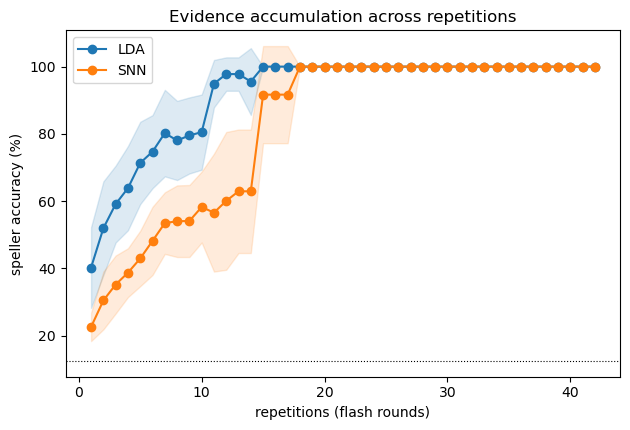

In [10]:
def char_accuracy(tr):
    cum = np.cumsum(np.nan_to_num(tr["inc"]), axis=1)
    rows = []
    for b in np.unique(tr["blk"]):
        idx = np.where(tr["blk"] == b)[0]; Rb = int(tr["R"][idx].min())
        tgt = int(np.argmax(tr["y"][idx])); s = int(tr["sess"][idx[0]])
        for r in range(1, Rb + 1):
            rows.append((s, r, int(np.argmax(cum[idx, r - 1]) == tgt)))
    return pd.DataFrame(rows, columns=["sess", "rep", "correct"])

char = {m: char_accuracy(trials[m]) for m in methods}
curve = {m: char[m].groupby(["sess", "rep"]).correct.mean().unstack("sess") for m in methods}
chance = 1 / N_OBJ
print("Speller accuracy (8-way, mean over sessions; chance = 12.5%):")
summary_char = pd.concat({f"{m}_{s}": (curve[m].mean(1) if s == "mean" else curve[m].std(1, ddof=1)).round(3)
                          for m in methods for s in ("mean", "sd")}, axis=1)
print(summary_char.to_string())
summary_char.to_csv(RESULTS / "speller_accuracy_vs_repetitions.csv")

fig, ax = plt.subplots(figsize=(6.4, 4.4))
for m, c in (("lda", "C0"), ("snn", "C1")):
    mu, sdv = curve[m].mean(1), curve[m].std(1, ddof=1)
    ax.plot(mu.index, mu.values * 100, "-o", color=c, label=m.upper()); ax.fill_between(mu.index, (mu - sdv) * 100, (mu + sdv) * 100, color=c, alpha=0.15)
ax.axhline(chance * 100, color="k", ls=":", lw=0.8); ax.set_xlabel("repetitions (flash rounds)"); ax.set_ylabel("speller accuracy (%)")
ax.set_title("Evidence accumulation across repetitions"); ax.legend(); plt.tight_layout()
plt.savefig(RESULTS / "fig2_speller_accuracy.png", dpi=200); plt.show()

## 10. Drift-diffusion model of the accumulated SNN evidence



In [11]:
def ddm_tables(v, a, rmax, n=121):
    # exact first-passage masses of a discrete-time Gaussian random walk (step ~ N(v, 1)), absorbing at +-a
    h = 2 * a / n
    edges = -a + h * np.arange(n + 1); centers = (edges[:-1] + edges[1:]) / 2
    cdf = norm.cdf(edges[None, :] - centers[:, None] - v)
    Tm = np.diff(cdf, axis=1); up = 1 - cdf[:, -1]; lo = cdf[:, 0]
    p = np.zeros(n); p[n // 2] = 1.0
    ups, los, surv, pos = [], [], [], []
    for _ in range(rmax):
        ups.append(p @ up); los.append(p @ lo); p = p @ Tm
        surv.append(p.sum()); pos.append(p[centers > 0].sum())
    return np.array(ups), np.array(los), np.array(surv), np.array(pos)

def run_policy(cum, R, theta):
    n = len(R); choice = np.zeros(n, int); decision = np.zeros(n, int); rt = R.copy()
    for i in range(n):
        c = cum[i, :R[i]]
        hit = np.where(np.abs(c) >= theta)[0]
        if len(hit):
            choice[i] = decision[i] = 1 if c[hit[0]] > 0 else -1; rt[i] = hit[0] + 1
        else:
            decision[i] = 1 if c[-1] > 0 else -1
    return choice, decision, rt

def fit_ddm(y, choice, rt, v0, a0, n=121):
    rmax = int(rt.max())
    def nll(p):
        vT, vN, la = p; a = np.exp(la); ll = 0.0
        for c, v in ((1, vT), (0, vN)):
            up, lo, sv, _ = ddm_tables(v, a, rmax, n)
            m = y == c; ch = choice[m]; r = rt[m] - 1
            pr = np.where(ch == 1, up[r], np.where(ch == -1, lo[r], sv[r]))
            ll += np.log(np.maximum(pr, 1e-12)).sum()
        return -ll
    r = minimize(nll, [v0[0], v0[1], np.log(a0)], method="Nelder-Mead", options=dict(xatol=1e-3, fatol=1e-3, maxiter=600))
    return r.x[0], r.x[1], float(np.exp(r.x[2])), float(r.fun)

def ddm_predict(vT, vN, a, R, y, n=121):
    rmax = int(R.max()); out = {}
    for c, v in ((1, vT), (0, vN)):
        up, lo, sv, pos = ddm_tables(v, a, rmax, n)
        rr = np.arange(1, rmax + 1); m = (y == c); i = R[m] - 1
        p_up = np.cumsum(up)[i] + pos[i]                       # declared "target", timeouts decided by sign
        ert = np.cumsum(rr * (up + lo))[i] + R[m] * sv[i]
        out[c] = (p_up.mean(), ert.mean(), m.sum())
    hit, rt1, n1 = out[1]; fa, rt0, n0 = out[0]
    return dict(hit=hit, fa=fa, bacc=(hit + 1 - fa) / 2, rt=(rt1 * n1 + rt0 * n0) / (n1 + n0))

def empirical(cum, R, y, theta):
    ch, dec, rt = run_policy(cum, R, theta)
    hit = (dec[y == 1] == 1).mean(); fa = (dec[y == 0] == 1).mean()
    return dict(hit=hit, fa=fa, bacc=(hit + 1 - fa) / 2, rt=rt.mean(), timeout=(ch == 0).mean()), ch, dec, rt

# ---- parameter recovery self-test: simulate a known DDM and check the fit recovers it ----
_rs = np.random.default_rng(0); _n = 1500; _y = (np.arange(_n) % 4 == 0).astype(int)
_R = np.full(_n, 8); _cum = np.cumsum(_rs.normal(np.where(_y == 1, 0.45, -0.30)[:, None], 1.0, (_n, 8)), axis=1)
_ch, _dec, _rt = run_policy(_cum, _R, 2.0)
_fit = fit_ddm(_y, _ch, _rt, (0.2, -0.2), 1.5)
print(f"Recovery test (true vT=0.45, vN=-0.30, a=2.0): fitted vT={_fit[0]:.2f}, vN={_fit[1]:.2f}, a={_fit[2]:.2f}")

Recovery test (true vT=0.45, vN=-0.30, a=2.0): fitted vT=0.43, vN=-0.27, a=2.06


method  session  dprime  v_target  v_nontarget  a_fit  a_policy  emp_hit  pred_hit  emp_fa  pred_fa  emp_rt  pred_rt
   snn        0   0.524     0.470       -0.239  6.339     5.721    0.857     0.895   0.243    0.270   7.000    7.035
   snn        1   0.581     0.351       -0.228  4.224     5.163    0.754     0.845   0.230    0.247   7.947    7.887
   snn        2   0.581     0.261       -0.147  4.654     5.164    0.762     0.769   0.270    0.330   8.008    7.970
   snn        3   0.532     0.275       -0.277  5.818     5.638    0.833     0.800   0.173    0.190   9.328    9.320
   snn        4   0.537     0.251       -0.279  5.137     5.588    0.735     0.742   0.267    0.247   6.371    6.358
   snn        5   0.629     0.282       -0.299  5.082     4.771    0.820     0.794   0.173    0.185   8.336    8.291
   snn        6   0.635     0.134       -0.289  4.476     4.727    0.619     0.648   0.181    0.196   7.784    7.860
   lda        0   0.896     0.498       -0.454  3.884     3.349 

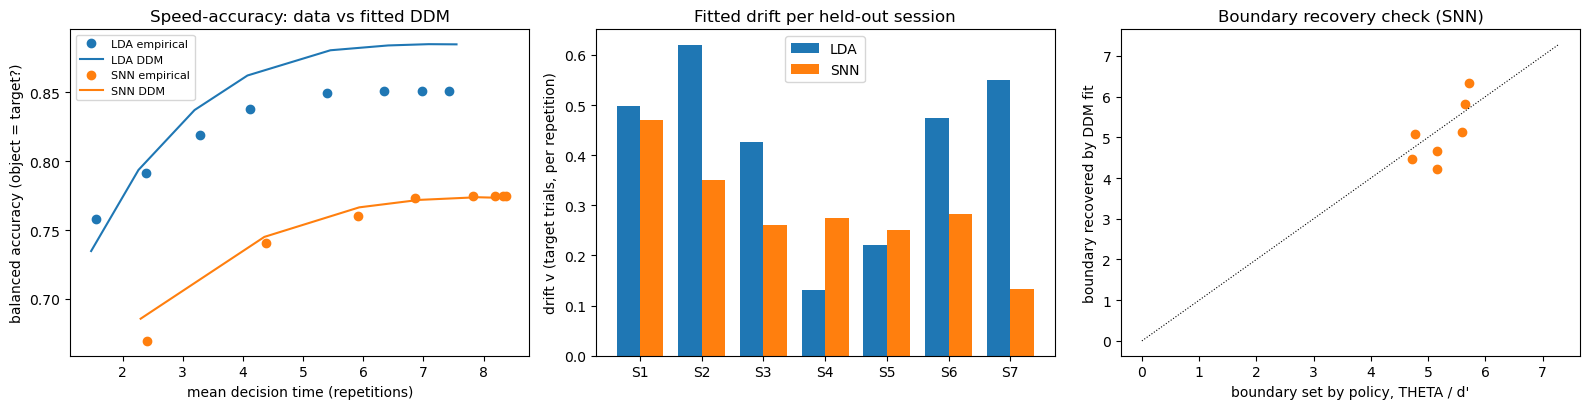

In [12]:
ddm_rows, sweep_rows = [], []
for m in methods:
    tr = trials[m]
    for k in sess_eval:
        msk = tr["sess"] == k
        inc, R, y = tr["inc"][msk], tr["R"][msk], tr["y"][msk]
        d = dprime[m][k]
        cum = np.cumsum(np.nan_to_num(inc), axis=1)
        emp, ch, dec, rt = empirical(cum, R, y, THETA_REF)
        w = np.nan_to_num(inc) / d                                           # unit-noise increments
        valid = ~np.isnan(inc)
        v_mom = (w[valid & (y == 1)[:, None]].mean(), w[valid & (y == 0)[:, None]].mean())
        vT, vN, a_fit, nll = fit_ddm(y, ch, rt, v_mom, THETA_REF / d)
        pred = ddm_predict(vT, vN, a_fit, R, y)
        ddm_rows.append(dict(method=m, session=int(k), dprime=d, v_target=vT, v_nontarget=vN, a_fit=a_fit,
                             a_policy=THETA_REF / d, v_moment_T=v_mom[0], v_moment_N=v_mom[1],
                             emp_hit=emp["hit"], pred_hit=pred["hit"], emp_fa=emp["fa"], pred_fa=pred["fa"],
                             emp_rt=emp["rt"], pred_rt=pred["rt"], timeout=emp["timeout"], nll=nll, n_trials=len(y)))
        for th in THETAS:                                                       # speed-accuracy sweep, boundary only changes
            e, _, _, _ = empirical(cum, R, y, th); p = ddm_predict(vT, vN, th / d, R, y)
            sweep_rows.append(dict(method=m, session=int(k), theta=th, emp_bacc=e["bacc"], emp_rt=e["rt"],
                                   pred_bacc=p["bacc"], pred_rt=p["rt"]))
ddm_df, sweep_df = pd.DataFrame(ddm_rows), pd.DataFrame(sweep_rows)
ddm_df.to_csv(RESULTS / "ddm_fits_per_session.csv", index=False); sweep_df.to_csv(RESULTS / "speed_accuracy_sweep.csv", index=False)

show = ["method", "session", "dprime", "v_target", "v_nontarget", "a_fit", "a_policy", "emp_hit", "pred_hit", "emp_fa", "pred_fa", "emp_rt", "pred_rt"]
print(ddm_df[show].round(3).to_string(index=False))
print("\nMean over sessions (SD in brackets):")
for m in methods:
    g = ddm_df[ddm_df.method == m]
    print(f"  {m.upper()}: v_target {g.v_target.mean():.3f} ({g.v_target.std(ddof=1):.3f}) | v_nontarget {g.v_nontarget.mean():.3f} "
          f"({g.v_nontarget.std(ddof=1):.3f}) | a {g.a_fit.mean():.2f} (policy {g.a_policy.mean():.2f}) | decision time {g.emp_rt.mean():.2f} reps")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for m, c in (("lda", "C0"), ("snn", "C1")):
    g = sweep_df[sweep_df.method == m].groupby("theta")[["emp_rt", "emp_bacc", "pred_rt", "pred_bacc"]].mean()
    ax[0].plot(g.emp_rt, g.emp_bacc, "o", color=c, label=f"{m.upper()} empirical"); ax[0].plot(g.pred_rt, g.pred_bacc, "-", color=c, label=f"{m.upper()} DDM")
ax[0].set_xlabel("mean decision time (repetitions)"); ax[0].set_ylabel("balanced accuracy (object = target?)")
ax[0].set_title("Speed-accuracy: data vs fitted DDM"); ax[0].legend(fontsize=8)
xs = np.arange(len(sess_eval)); w = 0.38
for j, (m, c) in enumerate((("lda", "C0"), ("snn", "C1"))):
    g = ddm_df[ddm_df.method == m]
    ax[1].bar(xs + (j - 0.5) * w, g.v_target, w, color=c, label=m.upper())
ax[1].set_xticks(xs); ax[1].set_xticklabels([f"S{int(s) + 1}" for s in sess_eval]); ax[1].set_ylabel("drift v (target trials, per repetition)")
ax[1].set_title("Fitted drift per held-out session"); ax[1].legend()
g = ddm_df[ddm_df.method == "snn"]
ax[2].scatter(g.a_policy, g.a_fit, color="C1"); lim = [0, max(g.a_policy.max(), g.a_fit.max()) * 1.15]
ax[2].plot(lim, lim, "k:", lw=0.8); ax[2].set_xlabel("boundary set by policy, THETA / d'"); ax[2].set_ylabel("boundary recovered by DDM fit")
ax[2].set_title("Boundary recovery check (SNN)")
plt.tight_layout(); plt.savefig(RESULTS / "fig3_ddm.png", dpi=200); plt.show()

## 11. Does the block-level drift predict whether the block is decided correctly?

To avoid circularity, drift is estimated from the **odd** repetitions of a block (mean SNN evidence for the true target object, and its margin over the other objects), and correctness comes from the **even** repetitions only.

In [13]:
def block_level(tr):
    rows = []
    for b in np.unique(tr["blk"]):
        idx = np.where(tr["blk"] == b)[0]; Rb = int(tr["R"][idx].min())
        if Rb < 4: continue
        inc = tr["inc"][idx][:, :Rb]; tgt = int(np.argmax(tr["y"][idx]))
        odd, even = inc[:, 0::2], inc[:, 1::2]
        rows.append(dict(sess=int(tr["sess"][idx[0]]), drift=odd[tgt].mean(),
                         margin=odd[tgt].mean() - np.delete(odd, tgt, axis=0).mean(),
                         correct=int(np.argmax(even.sum(1)) == tgt)))
    return pd.DataFrame(rows)

bl = block_level(trials["snn"])
if bl.correct.nunique() == 2:
    print(f"Blocks: {len(bl)}, correct (even repetitions): {bl.correct.mean():.1%}")
    print(f"AUC of odd-repetition margin for predicting even-repetition correctness: {roc_auc_score(bl.correct, bl.margin):.3f}")
    print(f"Mean target drift  correct blocks {bl[bl.correct == 1].drift.mean():.3f}  vs  incorrect blocks {bl[bl.correct == 0].drift.mean():.3f}")
else:
    print("All blocks were decided identically; not enough variation for this analysis.")

Blocks: 452, correct (even repetitions): 41.8%
AUC of odd-repetition margin for predicting even-repetition correctness: 0.559
Mean target drift  correct blocks 0.207  vs  incorrect blocks 0.132


In [14]:
# ---------------- manuscript-ready summary ----------------
print("=" * 78); print("SUMMARY"); print("=" * 78)
print(f"Sessions evaluated (leave-one-session-out): {len(sess_eval)}")
print(f"Single-trial AUC  SNN {res_auc.auc_snn.mean():.3f} +/- {res_auc.auc_snn.std(ddof=1):.3f}   LDA {res_auc.auc_lda.mean():.3f} +/- {res_auc.auc_lda.std(ddof=1):.3f}")
print(f"Evidence E(t): peak AUC {mean_curve.max():.3f} at {t_ms[peak_i]:.0f} ms, onset latency (median over sessions) "
      f"{np.nanmedian(list(onset_ms.values())):.0f} ms" if np.isfinite(list(onset_ms.values())).any() else "Evidence E(t): no sustained significant onset found")
for m in methods:
    c = curve[m].mean(1); last = c.index.max()
    print(f"Speller accuracy {m.upper()}: " + ", ".join(f"{r} rep {c.loc[r] * 100:.0f}%" for r in (1, 2, 3, 5, last) if r in c.index))
g = ddm_df[ddm_df.method == "snn"]
print(f"DDM (SNN evidence, THETA={THETA_REF}): v_target {g.v_target.mean():.3f} +/- {g.v_target.std(ddof=1):.3f}, "
      f"a {g.a_fit.mean():.2f}, decision time {g.emp_rt.mean():.2f} repetitions" +
      (f" = {g.emp_rt.mean() * SEC_PER_REP:.1f} s" if SEC_PER_REP else ""))
np.savez_compressed(RESULTS / "scores_and_evidence.npz", sess=sess_all, blk=blk_all, obj=ev_all, rep=rep_all, y=y_all,
                    score_snn=score["snn"], score_lda=score["lda"], llr_snn=llr["snn"], llr_lda=llr["lda"], E_traj=E_traj)
print("\nSaved CSVs, figures and scores to:", RESULTS.resolve())

SUMMARY
Sessions evaluated (leave-one-session-out): 7
Single-trial AUC  SNN 0.663 +/- 0.022   LDA 0.781 +/- 0.048
Evidence E(t): peak AUC 0.657 at 568 ms, onset latency (median over sessions) 472 ms
Speller accuracy SNN: 1 rep 23%, 2 rep 30%, 3 rep 35%, 5 rep 43%, 42 rep 100%
Speller accuracy LDA: 1 rep 40%, 2 rep 52%, 3 rep 59%, 5 rep 71%, 42 rep 100%
DDM (SNN evidence, THETA=3.0): v_target 0.289 +/- 0.103, a 5.10, decision time 7.82 repetitions

Saved CSVs, figures and scores to: E:\IIT KGP IEEE\Code\results_snn_ddm
